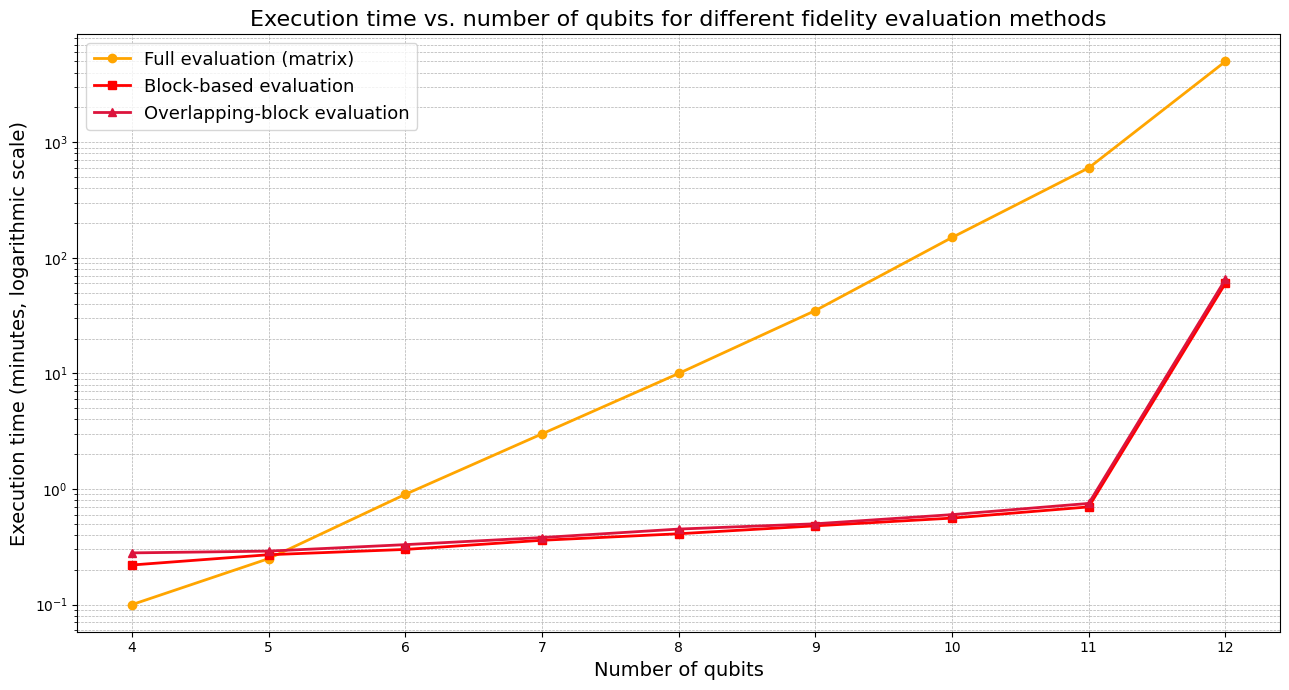

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data (replace with your exact data if needed)
qubits = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12])
full_eval = np.array([0.1, 0.25, 0.9, 3, 10, 35, 150, 600, 5000])
block_eval = np.array([0.22, 0.27, 0.30, 0.36, 0.41, 0.48, 0.56, 0.70, 60])
overlap_eval = np.array([0.28, 0.29, 0.33, 0.38, 0.45, 0.50, 0.60, 0.75, 65])

plt.figure(figsize=(13,7))
plt.yscale("log")

plt.plot(qubits, full_eval, '-o', color='orange', label='Full evaluation (matrix)', linewidth=2)
plt.plot(qubits, block_eval, '-s', color='red', label='Block-based evaluation', linewidth=2)
plt.plot(qubits, overlap_eval, '-^', color='crimson', label='Overlapping-block evaluation', linewidth=2)

plt.title("Execution time vs. number of qubits for different fidelity evaluation methods", fontsize=16)
plt.ylabel("Execution time (minutes, logarithmic scale)", fontsize=14)
plt.xlabel("Number of qubits", fontsize=14)

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()


In [3]:
from __future__ import annotations

import copy
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Set, Tuple
from collections import defaultdict

import numpy as np
import networkx as nx
from joblib import Parallel, delayed
from qiskit import QuantumCircuit, transpile, QuantumRegister
from qiskit.quantum_info import Operator
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import CommutationAnalysis, CommutativeCancellation, Optimize1qGates
from deap import base, creator, tools

import matplotlib.pyplot as plt
import os

def save_plot(name: str, out_dir="out_figs"):
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(os.path.join(out_dir, f"{name}.png"), dpi=300)


def plot_convergence(hist_eps, save_as: Optional[str] = None):
    plt.figure(); plt.plot(range(len(hist_eps)), hist_eps, marker="o")
    plt.yscale("log"); plt.xlabel("Génération"); plt.ylabel(r"$1\!-\!F$ (log)")
    plt.title("Convergence de la fidélité"); plt.grid(True); plt.tight_layout()
    if save_as: save_plot(save_as)
    plt.close()

def plot_pareto(front, save_as: Optional[str] = None):
    costs = [i.fitness.values[2] for i in front]
    depths = [i.fitness.values[1] for i in front]
    eps = [1 - i.fitness.values[0] for i in front]
    plt.figure(); sc = plt.scatter(costs, depths, c=eps, cmap="viridis")
    plt.colorbar(sc, label=r"$\varepsilon$ (1-F)")
    plt.xlabel("Coût chrom."); plt.ylabel("Profondeur"); plt.title("Front de Pareto local")
    plt.gca().invert_yaxis(); plt.tight_layout()
    if save_as: save_plot(save_as)
    plt.close()
    
    
def extract_interblock_gates(qc: QuantumCircuit, blocks: List[Set[int]]) -> List[Tuple]:
    bmap = {q: i for i, bl in enumerate(blocks) for q in bl}
    interblock_gates = []
    for inst, qargs, cargs in qc.data:
        if len(qargs) < 2:
            continue
        qubit_indices = {qc.find_bit(q).index for q in qargs}
        involved_blocks = {bmap.get(q) for q in qubit_indices}
        if len(involved_blocks) > 1:
            interblock_gates.append((inst, qargs, cargs))
    return interblock_gates
    
    
def build_interaction_graph(qc: QuantumCircuit) -> nx.Graph:
    """Graphe non orienté pondéré par le *nombre* total de portes bi‑qubit
    entre chaque paire de qubits (CX, CZ, RZZ)."""
    G = nx.Graph(); G.add_nodes_from(range(qc.num_qubits))
    for inst, qargs, _ in qc.data:
        if inst.name in {"cx", "cz", "rzz"} and len(qargs) == 2:
            i, j = [qc.find_bit(q).index for q in qargs]
            w = G.get_edge_data(i, j, default={"weight": 0})["weight"] + 1
            G.add_edge(i, j, weight=w)
    return G

def _partition_metis(graph: nx.Graph) -> List[Set[int]]:
    import nxmetis  # type: ignore
    _, parts = nxmetis.partition(graph, 2)
    return [set(p) for p in parts]


def _partition_kl(graph: nx.Graph) -> List[Set[int]]:
    from networkx.algorithms.community import kernighan_lin_bisection
    a, b = kernighan_lin_bisection(graph); return [set(a), set(b)]


def multilevel_partition(graph: nx.Graph, max_block_size: int) -> List[Set[int]]:
    """Partition récursive jusqu’à `max_block_size`."""
    if len(graph) <= max_block_size:
        return [set(graph.nodes())]
    try:
        parts = _partition_metis(graph)
    except Exception:
        parts = _partition_kl(graph)
    res: List[Set[int]] = []
    for p in parts:
        res.extend(multilevel_partition(graph.subgraph(p), max_block_size))
    return res

def _interblock_gate_cost(qc: QuantumCircuit, blk0: Set[int], blk1: Set[int]) -> int:
    cost = 0
    for inst, qargs, _ in qc.data:
        if len(qargs) < 2:
            continue
        qs = {qc.find_bit(q).index for q in qargs}
        if qs & blk0 and qs & blk1:
            cost += 1
    return cost


def refine_partition_kl(qc: QuantumCircuit, blocks: List[Set[int]], *, max_iter: int = 10) -> List[Set[int]]:
    """Affinage Kernighan‑Lin pondéré par le *nombre* de portes inter‑blocs."""
    if len(blocks) < 2:
        return blocks
    a, b = blocks[0].copy(), blocks[1].copy()
    best_cost = _interblock_gate_cost(qc, a, b)
    improved, it = True, 0
    while improved and it < max_iter:
        improved = False; it += 1
        gain_best, q_best, side = 0, None, None
        # — Déplacements potentiels de a → b
        for q in list(a):
            gain = best_cost - _interblock_gate_cost(qc, a - {q}, b | {q})
            if gain > gain_best:
                gain_best, q_best, side = gain, q, "a2b"
        # — … et b → a
        for q in list(b):
            gain = best_cost - _interblock_gate_cost(qc, a | {q}, b - {q})
            if gain > gain_best:
                gain_best, q_best, side = gain, q, "b2a"
        # — Appliquer le meilleur gain si positif
        if gain_best > 0 and q_best is not None:
            improved = True; best_cost -= gain_best
            if side == "a2b":
                a.remove(q_best); b.add(q_best)
            else:
                b.remove(q_best); a.add(q_best)
    blocks[0], blocks[1] = a, b
    return blocks


def extract_commuting_sets(qc: QuantumCircuit):
    """Retourne une liste de *layers* de portes qui commutent toutes entre elles."""
    try:
        from qiskit.converters import circuit_to_dag
        dag = circuit_to_dag(qc)
        PassManager(CommutationAnalysis()).run(dag)
        layers, seen = [], set()
        for node in dag.topological_op_nodes():
            if node in seen:
                continue
            group = [g for g in node.commutation_set if g.type == "op"]
            layers.append(group); seen.update(group)
        return layers
    except Exception:  # fallback naïf
        active, lvl, levels = set(), 0, defaultdict(list)
        for inst, qargs, _ in qc.data:
            qub = {qc.find_bit(q).index for q in qargs}
            if active & qub:
                lvl += 1; active.clear()
            active.update(qub); levels[lvl].append((inst, qargs))
        return list(levels.values())
    
    
    
    
    
def select_interface_qubits(blocks: List[Set[int]], k: int = 1) -> Dict[int, Set[int]]:
    """Réserve pour chaque bloc ses `k` plus petits indices comme qubits interface."""
    return {i: set(sorted(bl)[:k]) for i, bl in enumerate(blocks)}


def identify_highly_interactive_qubits(qc: QuantumCircuit, blocks: List[Set[int]], threshold_ratio: float = 0.5) -> Dict[int, int]:
    """
    Identifies qubits that are highly involved in inter-block entanglement,
    potentially candidates for 'duplication'.

    Args:
        qc: The quantum circuit.
        blocks: The list of qubit blocks.
        threshold_ratio: A qubit is considered highly interactive if its inter-block
                         gate count is above this ratio of its total gate count.

    Returns:
        A dictionary mapping a qubit index to the block it interacts most with,
        if it crosses the threshold.
        Example: `{original_q_idx: target_block_idx_for_duplication}`
    """
    if len(blocks) < 2:
        return {}

    # Map each qubit to its block ID
    bmap = {q: i for i, bl in enumerate(blocks) for q in bl}

    # Count inter-block gates per qubit and its total gates
    qubit_inter_block_counts = defaultdict(lambda: defaultdict(int)) # {q_idx: {block_id_it_interacts_with: count}}
    qubit_total_gate_counts = defaultdict(int)

    for inst, qargs, _ in qc.data:
        q_indices = {qc.find_bit(q).index for q in qargs}
        if len(q_indices) < 2: # Only consider multi-qubit gates
            continue

        involved_blocks = {bmap.get(q_idx) for q_idx in q_indices if q_idx in bmap}
        if len(involved_blocks) > 1: # It's an inter-block gate
            for q_idx in q_indices:
                if q_idx not in bmap: continue # Skip if qubit isn't mapped to a block
                qubit_total_gate_counts[q_idx] += 1
                for block_id in involved_blocks:
                    if block_id is not None and bmap[q_idx] != block_id: # Count interaction with *other* block
                        qubit_inter_block_counts[q_idx][block_id] += 1
        else: # Intra-block gate
            for q_idx in q_indices:
                if q_idx not in bmap: continue
                qubit_total_gate_counts[q_idx] += 1

    highly_interactive: Dict[int, int] = {}
    for q_idx, inter_counts in qubit_inter_block_counts.items():
        if qubit_total_gate_counts[q_idx] == 0: # Avoid division by zero
            continue

        # Find the block with which this qubit has the most inter-block interactions
        if inter_counts: # Ensure there are inter-block counts
            max_inter_block_id = max(inter_counts, key=inter_counts.get)
            # If the ratio of inter-block gates (with that specific block) to total gates is high
            if inter_counts[max_inter_block_id] / qubit_total_gate_counts[q_idx] >= threshold_ratio:
                # Add to candidates only if the qubit is not already in the target block
                if q_idx not in blocks[max_inter_block_id]:
                    highly_interactive[q_idx] = max_inter_block_id

    return highly_interactive

'''def apply_interface_swaps(qc: QuantumCircuit, blocks: List[Set[int]], *,
                          k_interface: int = 1,
                          highly_interactive_qubits: Optional[Dict[int, int]] = None) -> QuantumCircuit:
    """Redirige toute porte inter‑blocs via des qubits *interface* locaux ou des qubits 'dupliqués'."""

    iface = select_interface_qubits(blocks, k_interface)
    current_blocks = [s.copy() for s in blocks]
    bmap = {q: i for i, bl in enumerate(current_blocks) for q in bl}

    num_original_qubits = qc.num_qubits
    highest_original_q_idx = num_original_qubits - 1 if num_original_qubits > 0 else -1
    new_num_qubits = num_original_qubits

    duplicate_map: Dict[int, int] = {}
    initial_entanglement_gates: List[Tuple] = []

    if highly_interactive_qubits:
        all_used_qubits = set().union(*current_blocks)
        next_available_q_idx = num_original_qubits

        for original_q, target_block_idx in highly_interactive_qubits.items():
            if bmap.get(original_q) == target_block_idx:
                continue
            duplicate_q = next_available_q_idx
            next_available_q_idx += 1
            new_num_qubits = max(new_num_qubits, duplicate_q + 1)

            duplicate_map[original_q] = duplicate_q
            print(f"  📞 Duplicating qubit {original_q} (from block {bmap.get(original_q)}) "
                  f"into block {target_block_idx} using new qubit {duplicate_q}")

            current_blocks[target_block_idx].add(duplicate_q)
            bmap[duplicate_q] = target_block_idx

            initial_entanglement_gates.append(('h', original_q))
            initial_entanglement_gates.append(('cx', original_q, duplicate_q))

    new_qc = QuantumCircuit(new_num_qubits)

    # ✅ Correction ici : unpacking conditionnel
    for gate in initial_entanglement_gates:
        if gate[0] == 'h':
            _, q1 = gate
            new_qc.h(q1)
        elif gate[0] == 'cx':
            _, q1, q2 = gate
            new_qc.cx(q1, q2)

    for inst, qargs, cargs in qc.data:
        mapped_qargs = list(qargs)
        rerouted_by_duplication = False

        for idx, q in enumerate(qargs):
            q_idx = qc.find_bit(q).index
            original_block_of_q = bmap.get(q_idx)
            qubits_in_current_gate_indices = {temp_qc.find_bit(q).index for temp_q in qargs}
            involved_blocks_for_gate = {bmap.get(qi) for qi in qubits_in_current_gate_indices if qi in bmap}

            if len(involved_blocks_for_gate) > 1:
                if q_idx in duplicate_map and bmap.get(duplicate_map[q_idx]) in involved_blocks_for_gate:
                    mapped_qargs[idx] = new_qc.qubits[duplicate_map[q_idx]]
                    rerouted_by_duplication = True

        final_gate_q_indices = {q_obj.index for q_obj in mapped_qargs}
        final_involved_blocks = {bmap.get(q_idx) for q_idx in final_gate_q_indices if q_idx in bmap}

        if len(final_involved_blocks) <= 1 and not rerouted_by_duplication:
            new_qc.append(inst, [new_qc.qubits[qc.find_bit(q).index] for q in qargs], cargs)
            continue

        pre_swaps, post_swaps = [], []
        if not rerouted_by_duplication:
            for idx, q in enumerate(qargs):
                q_idx = qc.find_bit(q).index
                blk_of_q = bmap.get(q_idx)
                if blk_of_q is None: continue
                if q_idx not in iface[blk_of_q]:
                    target_iface_q = next(iter(iface[blk_of_q]), None)
                    if target_iface_q is not None:
                        current_q_indices_in_mapped = {q_obj.index for q_obj in mapped_qargs}
                        if target_iface_q not in current_q_indices_in_mapped:
                            pre_swaps.append((q_idx, target_iface_q))
                            post_swaps.append((q_idx, target_iface_q))
                            mapped_qargs[idx] = new_qc.qubits[target_iface_q]

        for a, b in pre_swaps:
            new_qc.swap(a, b)

        final_gate_qargs_for_append = [new_qc.qubits[q_obj.index] for q_obj in mapped_qargs]
        new_qc.append(inst, final_gate_qargs_for_append, cargs)

        for a, b in reversed(post_swaps):
            new_qc.swap(a, b)

    return new_qc
'''

def apply_interface_swaps(qc: QuantumCircuit, blocks: List[Set[int]], *,
                          k_interface: int = 1,
                          highly_interactive_qubits: Optional[Dict[int, int]] = None,
                          max_block_size: int = 6  # par sécurité pour duplication
                          ) -> QuantumCircuit:
    """Redirige toute porte inter‑blocs via des qubits *interface* ou des qubits dupliqués."""

    def perform_qubit_duplication(qc: QuantumCircuit, blocks: List[Set[int]],
                                  highly_interactive: Dict[int, int],
                                  max_block_size: int) -> Tuple[Dict[int, int], List[Tuple[str, int, int]]]:
        """Retourne un mapping {original → dupliqué} et les portes H/CX à ajouter"""
        duplicate_map = {}
        entangle_gates = []
        next_q_idx = qc.num_qubits
        bmap = {q: i for i, bl in enumerate(blocks) for q in bl}

        for q_orig, target_block in highly_interactive.items():
            if bmap.get(q_orig) == target_block:
                continue
            if len(blocks[target_block]) + 1 > max_block_size:
                print(f"⚠️ Bloc {target_block} plein — pas de duplication pour q{q_orig}")
                continue

            q_dup = next_q_idx
            next_q_idx += 1
            duplicate_map[q_orig] = q_dup
            blocks[target_block].add(q_dup)
            bmap[q_dup] = target_block

            print(f"🔁 Duplication q{q_orig} → q{q_dup} dans bloc {target_block}")
            entangle_gates.append(('h', q_orig))
            entangle_gates.append(('cx', q_orig, q_dup))

        return duplicate_map, entangle_gates

    iface = select_interface_qubits(blocks, k_interface)
    current_blocks = [s.copy() for s in blocks]
    bmap = {q: i for i, bl in enumerate(current_blocks) for q in bl}

    duplicate_map: Dict[int, int] = {}
    initial_entanglement_gates: List[Tuple[str, int, int]] = []

    if highly_interactive_qubits:
        duplicate_map, initial_entanglement_gates = perform_qubit_duplication(
            qc, current_blocks, highly_interactive_qubits, max_block_size=max_block_size
        )
        bmap = {q: i for i, bl in enumerate(current_blocks) for q in bl}  # mise à jour après duplication

    #new_num_qubits = max(qc.num_qubits, *(duplicate_map.values()), default=qc.num_qubits) + 1
    new_num_qubits = max([qc.num_qubits] + list(duplicate_map.values()), default=qc.num_qubits) + 1
    new_qc = QuantumCircuit(new_num_qubits)

    for gate in initial_entanglement_gates:
        if gate[0] == 'h':
            _, q1 = gate
            new_qc.h(q1)
        elif gate[0] == 'cx':
            _, q1, q2 = gate
            new_qc.cx(q1, q2)

    for inst, qargs, cargs in qc.data:
        mapped_qargs = list(qargs)
        rerouted_by_duplication = False

        for idx, q in enumerate(qargs):
            q_idx = qc.find_bit(q).index
            original_block_of_q = bmap.get(q_idx)
            qubits_in_current_gate_indices = {temp_qc.find_bit(q).index for temp_q in qargs}
            involved_blocks_for_gate = {bmap.get(qi) for qi in qubits_in_current_gate_indices if qi in bmap}

            if len(involved_blocks_for_gate) > 1:
                if q_idx in duplicate_map and bmap.get(duplicate_map[q_idx]) in involved_blocks_for_gate:
                    mapped_qargs[idx] = new_qc.qubits[duplicate_map[q_idx]]
                    rerouted_by_duplication = True

        final_gate_q_indices = {q_obj.index for q_obj in mapped_qargs}
        final_involved_blocks = {bmap.get(q_idx) for q_idx in final_gate_q_indices if q_idx in bmap}

        if len(final_involved_blocks) <= 1 and not rerouted_by_duplication:
            new_qc.append(inst, [new_qc.qubits[qc.find_bit(q).index] for q in qargs], cargs)
            continue

        pre_swaps, post_swaps = [], []
        if not rerouted_by_duplication:
            for idx, q in enumerate(qargs):
                q_idx = qc.find_bit(q).index
                blk_of_q = bmap.get(q_idx)
                if blk_of_q is None: continue
                if q_idx not in iface[blk_of_q]:
                    target_iface_q = next(iter(iface[blk_of_q]), None)
                    if target_iface_q is not None:
                        current_q_indices_in_mapped = {q_obj.index for q_obj in mapped_qargs}
                        if target_iface_q not in current_q_indices_in_mapped:
                            cx.append((q_idx, target_iface_q))
                            post_swaps.append((q_idx, target_iface_q))
                            mapped_qargs[idx] = new_qc.qubits[target_iface_q]

        for a, b in pre_swaps:
            new_qc.swap(a, b)

        final_gate_qargs_for_append = [new_qc.qubits[q_obj.index] for q_obj in mapped_qargs]
        new_qc.append(inst, final_gate_qargs_for_append, cargs)

        for a, b in reversed(post_swaps):
            new_qc.swap(a, b)

    return new_qc




def extract_subcircuit(qc: QuantumCircuit, qubits: Set[int]) -> QuantumCircuit:
    sub = QuantumCircuit(len(qubits))
    idx = {q: i for i, q in enumerate(sorted(list(qubits)))} # Ensure consistent indexing
    for inst, qargs, cargs in qc.data:
        if all(qc.find_bit(q).index in qubits for q in qargs):
            remap = [sub.qubits[idx[qc.find_bit(q).index]] for q in qargs]
            sub.append(inst, remap, cargs)
    return sub

def recompose_from_blocks(
    qc_original: QuantumCircuit,
    block_subcircuits: List[Tuple[Set[int], QuantumCircuit]]
) -> QuantumCircuit:
    """
    Reconstruit un circuit global à partir du circuit original
    en remplaçant les portes intra-bloc par les versions optimisées
    tout en conservant l'ordre d'apparition des portes global.

    Args:
        qc_original: circuit initial (à suivre pour l’ordre)
        block_subcircuits: liste de (set_qubits_bloc, circuit_optimisé)

    Returns:
        Circuit recomposé (QuantumCircuit)
    """

    block_maps = []
    for block_qubits, sub in block_subcircuits:
        sorted_block = sorted(block_qubits)
        local_to_global = {i: q for i, q in enumerate(sorted_block)}
        global_to_local = {q: i for i, q in enumerate(sorted_block)}
        block_maps.append((set(sorted_block), sub, global_to_local))

    num_qubits = qc_original.num_qubits
    qc_recomposed = QuantumCircuit(num_qubits)
    subcircuit_cursors = [0 for _ in block_subcircuits]

    for inst, qargs, cargs in qc_original.data:
        q_indices = [qc_original.find_bit(q).index for q in qargs]
        inserted = False
        for idx, (block_qubits, sub, g2l) in enumerate(block_maps):
            if all(q in block_qubits for q in q_indices):
                if subcircuit_cursors[idx] >= len(sub.data):
                    raise ValueError(f"Trop de portes dans le bloc {idx} du circuit original.")
                inst_opt, qargs_opt, cargs_opt = sub.data[subcircuit_cursors[idx]]
                subcircuit_cursors[idx] += 1
                mapped_qargs = [qc_recomposed.qubits[sorted(block_qubits)[sub.find_bit(q).index]] for q in qargs_opt]
                qc_recomposed.append(inst_opt, mapped_qargs, cargs_opt)
                inserted = True
                break
        if not inserted:
            mapped_qargs = [qc_recomposed.qubits[i] for i in q_indices]
            qc_recomposed.append(inst, mapped_qargs, cargs)
    return qc_recomposed



def compute_fidelity(circ: QuantumCircuit, target: np.ndarray) -> float:
    # Handle circuits with different numbers of qubits (e.g., after duplication)
    circ_op = Operator(circ).data
    target_nqubits = int(np.log2(target.shape[0]))  # Correctly infer number of qubits from matrix size
    
    if circ.num_qubits > target_nqubits:
        # Pad the target unitary with identity to match circuit dimension
        target_op_padded = np.eye(2**circ.num_qubits, dtype=complex)
        target_op_padded[:target.shape[0], :target.shape[1]] = target
        target = target_op_padded
    elif circ.num_qubits < target_nqubits:
        raise ValueError("Circuit has fewer qubits than target operator, cannot compute fidelity directly.")
        
    return abs(np.trace(circ_op @ target.conj().T)) / (2 ** circ.num_qubits)

        
    return abs(np.trace(circ_op @ target.conj().T)) / (2 ** circ.num_qubits)

def cancel_inverse_gates(c: QuantumCircuit) -> QuantumCircuit:
    new, skip = QuantumCircuit(c.num_qubits), set()
    for i in range(len(c.data) - 1):
        if i in skip:
            continue
        g1, q1, _ = c.data[i]; g2, q2, _ = c.data[i + 1]
        if g1.name == g2.name and q1 == q2 and g1.name in {"x", "y", "z", "h", "cx"}:
            skip.add(i + 1); continue
        new.append(g1, q1)
    if (len(c.data) - 1) not in skip:
        g, q, _ = c.data[-1]; new.append(g, q)
    return new


def merge_rotations(c: QuantumCircuit) -> QuantumCircuit:
    new, i = QuantumCircuit(c.num_qubits), 0
    while i < len(c.data):
        g, q, _ = c.data[i]
        if g.name in {"rx", "ry", "rz"}:
            angle, j = g.params[0], i + 1
            while j < len(c.data):
                g2, q2, _ = c.data[j]
                if g2.name == g.name and q2 == q:
                    angle += g2.params[0]; j += 1
                else:
                    break
            getattr(new, g.name)(angle, q[0] ); i = j
        else:
            new.append(g, q); i += 1
    return new


def remove_negligible_rotations(c: QuantumCircuit, *, th: float = 1e-4) -> QuantumCircuit:
    new = QuantumCircuit(c.num_qubits)
    for g, q, _ in c.data:
        if g.name in {"rx", "ry", "rz"} and abs(g.params[0]) < th:
            continue
        new.append(g, q)
    return new


def compress_custom(circ: QuantumCircuit) -> QuantumCircuit:
    return remove_negligible_rotations(merge_rotations(cancel_inverse_gates(circ)))


def qiskit_opt_pass(c: QuantumCircuit) -> QuantumCircuit:
    return PassManager([Optimize1qGates(), CommutativeCancellation()]).run(c)



def optimise_block_nsga2(qc_target: QuantumCircuit, *, generations=500, pop_size=300, n_jobs=-1):
    nq = qc_target.num_qubits; U_target = Operator(qc_target).data
    gate_pool = ["h", "x", "y", "z", "rx", "ry", "rz", "cx", "cz", "rzz"]

    def gen_gene():
        g = random.choice(gate_pool); tgt = random.randrange(nq)
        if g in {"rx", "ry", "rz"}:
            return (g, tgt, None, random.uniform(0, 2 * math.pi))
        if g == "rzz":
            ctrl = random.choice([q for q in range(nq) if q != tgt])
            return (g, tgt, ctrl, random.uniform(0, 2 * math.pi))
        if g in {"cx", "cz"}:
            ctrl = random.choice([q for q in range(nq) if q != tgt])
            return (g, tgt, ctrl, None)
        return (g, tgt, None, None)

    def build(ch):
        qc = QuantumCircuit(nq)
        for g, t, ctrl, a in ch:
            if g == "rzz":
                qc.rzz(a, ctrl, t)
            elif g in {"cx", "cz"}:
                getattr(qc, g)(ctrl, t)
            elif g in {"rx", "ry", "rz"}:
                getattr(qc, g)(a, t)
            else:
                getattr(qc, g)(t)
        return qc
    def compute_gate_cost(qc: QuantumCircuit) -> float:
        """Calcule le coût basé sur Lee et al. (2006)."""
        cost_table = {"x": 1, "z": 1, "s": 1, "sdg": 1, "t": 1, "tdg": 1, "h": 2, "cx": 5, "cz": 5, "ccx": 13   }
        return sum(cost_table.get(inst.name.lower(), 1) for inst, _, _ in qc.data)


    def eval_ind(ind):
        qc = build(ind); fid = compute_fidelity(qc, U_target)
        depth = transpile(qc, basis_gates=["cx", "rz", "sx"], optimization_level=1).depth()
        cost = compute_gate_cost(qc)
        return fid, depth, len(ind)

    if not hasattr(creator, "FitnessMulti"):
        creator.create("FitnessMulti", base.Fitness, weights=(1, -1, -1))
        creator.create("Individual", list, fitness=creator.FitnessMulti)
    tb = base.Toolbox(); tb.register("gene", gen_gene)
    tb.register("individual", tools.initRepeat, creator.Individual, tb.gene, 15)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("mate", tools.cxTwoPoint)
    tb.register("mutate", lambda ind: (ind.__setitem__(random.randrange(len(ind)), gen_gene()) or ind))
    tb.register("select", tools.selNSGA2)

    pop = tb.population(pop_size)
    fits = Parallel(n_jobs)(delayed(eval_ind)(i) for i in pop)
    for ind, fit in zip(pop, fits):
        ind.fitness.values = fit
    hist_eps = [1 - max(pop, key=lambda i: i.fitness.values[0]).fitness.values[0]]

    for gen in range(generations):
        tools.emo.assignCrowdingDist(pop)
        offspring = tools.selTournamentDCD(pop, len(pop)); offspring = list(map(tb.clone, offspring))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < 0.9:
                tb.mate(c1, c2); del c1.fitness.values, c2.fitness.values
        for ind in offspring:
            if random.random() < 0.9:
                tb.mutate(ind); del ind.fitness.values
        invalid = [i for i in offspring if not i.fitness.valid]
        fits = Parallel(n_jobs)(delayed(eval_ind)(i) for i in invalid)
        for ind, fit in zip(invalid, fits):
            ind.fitness.values = fit
        pop = tb.select(pop + offspring, k=len(pop))
        best = max(pop, key=lambda i: i.fitness.values[0])
        hist_eps.append(1 - best.fitness.values[0])
        print(f"Gen {gen + 1:>4} | Fid {best.fitness.values[0]:.4f} | D {best.fitness.values[1]:>3} | C {best.fitness.values[2]:>3}")
        

    front = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    plot_convergence(hist_eps, save_as=f"block_fid_conv_{nq}q")
    plot_pareto(front, save_as=f"block_pareto_{nq}q")
    
    return build(max(pop, key=lambda i: i.fitness.values[0]))


@dataclass
class InjectionGate:
    gate: str           # "cx", "cz" ou "rzz"
    q1: int             # qubit contrôle (bloc 0)
    q2: int             # qubit cible     (bloc 1)
    theta: Optional[float] # angle pour rzz, sinon None
    enabled: bool = True

    def copy(self) -> "InjectionGate":
        return InjectionGate(self.gate, self.q1, self.q2, self.theta, self.enabled)

def _sa_build_circuit(base: QuantumCircuit, injections: Sequence[InjectionGate]) -> QuantumCircuit:
    circ = base.copy()
    for inj in injections:
        if not inj.enabled:
            continue
        if inj.gate == "rzz":
            circ.rzz(inj.theta, inj.q1, inj.q2)
        else:
            getattr(circ, inj.gate)(inj.q1, inj.q2)
    circ = transpile(circ, basis_gates=["cx", "rz", "sx"], optimization_level=1)
    return circ


def _sa_energy(injections: Sequence[InjectionGate], *, base: QuantumCircuit, target_U: np.ndarray,
               α: float, β: float, γ: float, δ: float, fid_tol: float,
               crosstalk_mat: Optional[np.ndarray]) -> float:
    cand = _sa_build_circuit(base, injections)
    n2q = sum(1 for inj in injections if inj.enabled)
    depth = cand.depth() or 0
    crosstalk = 0.0
    if crosstalk_mat is not None:
        for inj in injections:
            if inj.enabled:
                crosstalk += crosstalk_mat[inj.q1, inj.q2]
    fid = compute_fidelity(cand, target_U)
    fid_penalty = (1.0 - fid) / fid_tol
    return α * n2q + β * depth + γ * crosstalk + δ * fid_penalty


def _sa_rand_move(injections: Sequence[InjectionGate], blocks: List[Set[int]], *, rng: random.Random,
                   eps_theta: float = 0.1) -> List[InjectionGate]:
    moves = [
        "toggle",      # active/désactive une porte
        "swap_type",   # change CX↔CZ↔RZZ
        "shift",       # change les qubits (tjs inter‑blocs)
        "tune_theta",  # ajuste l’angle d’une RZZ
    ]
    choice = rng.choice(moves)
    cand = [inj.copy() for inj in injections]
    idx = rng.randrange(len(cand))
    inj = cand[idx]
    if choice == "toggle":
        inj.enabled = not inj.enabled
    elif choice == "swap_type":
        inj.gate = rng.choice([g for g in ("cx", "cz", "rzz") if g != inj.gate])
        inj.theta = None if inj.gate != "rzz" else rng.uniform(0, 2 * math.pi)
    elif choice == "shift":
        blk0, blk1 = blocks[0], blocks[1]
        inj.q1 = rng.choice(tuple(blk0)); inj.q2 = rng.choice(tuple(blk1))
    elif choice == "tune_theta" and inj.gate == "rzz":
        inj.theta = (inj.theta or 0.0) + rng.uniform(-eps_theta, eps_theta)
    return cand


def _sa_generate_pool(blocks: List[Set[int]], gate_types: Sequence[str], *, rng: random.Random,
                      n_candidates: int) -> List[InjectionGate]:
    blk0, blk1 = blocks[0], blocks[1]; pool: List[InjectionGate] = []
    for _ in range(n_candidates):
        gate = rng.choice(gate_types)
        q1 = rng.choice(tuple(blk0)); q2 = rng.choice(tuple(blk1))
        theta = rng.uniform(0, 2 * math.pi) if gate == "rzz" else None
        pool.append(InjectionGate(gate, q1, q2, theta, enabled=False))
    return pool

def sa_injection(base_qc: QuantumCircuit, blocks: List[Set[int]], *,
                 gate_types: Sequence[str] = ("cx", "cz", "rzz"),
                 n_candidates: int = 120,
                 fid_threshold: float = 0.999,
                 n_iters: int = 2000,
                 α: float = 1.0, β: float = 0.01, γ: float = 0.0, δ: float = 1e4,
                 schedule_alpha: float = 0.85,
                 seed: Optional[int] = None,
                 crosstalk_mat: Optional[np.ndarray] = None) -> Tuple[QuantumCircuit, List[Tuple[str, int, int, Optional[float]]]]:
    """Optimise les injections inter‑blocs via Recuit Simulé (SA).

    Retourne :
        * `final_circ` : circuit enrichi (+ compression rapide).
        * `kept`        : liste des tuples (gate, q1, q2, theta) *activés*.
    """
    if len(blocks) < 2:
        raise ValueError("sa_injection nécessite au moins deux blocs.")

    rng = random.Random(seed)
    injections = _sa_generate_pool(blocks, gate_types, rng=rng, n_candidates=n_candidates)
    target_U = Operator(base_qc).data

    # — Température initiale ~ 5 × σ(E) sur 30 échantillons
    sample_E = []
    for _ in range(30):
        tmp = _sa_rand_move(injections, blocks, rng=rng)
        e = _sa_energy(tmp, base=base_qc, target_U=target_U, α=α, β=β, γ=γ, δ=δ,
                         fid_tol=1.0 - fid_threshold, crosstalk_mat=crosstalk_mat)
        sample_E.append(e)
    T = 5.0 * (np.std(sample_E) or 1.0)

    best = copy.deepcopy(injections)
    E_best = _sa_energy(best, base=base_qc, target_U=target_U, α=α, β=β, γ=γ, δ=δ,
                         fid_tol=1.0 - fid_threshold, crosstalk_mat=crosstalk_mat)
    current, E_curr = copy.deepcopy(best), E_best

    for _ in range(n_iters):
        cand = _sa_rand_move(current, blocks, rng=rng)
        E_cand = _sa_energy(cand, base=base_qc, target_U=target_U, α=α, β=β, γ=γ, δ=δ,
                              fid_tol=1.0 - fid_threshold, crosstalk_mat=crosstalk_mat)
        ΔE = E_cand - E_curr
        accept = ΔE < 0 or rng.random() < math.exp(-ΔE / T)
        if accept:
            current, E_curr = cand, E_cand
            if E_curr < E_best:
                best, E_best = copy.deepcopy(current), E_curr
        T *= schedule_alpha

    final_circ = _sa_build_circuit(base_qc, best)
    fid_final = compute_fidelity(final_circ, target_U)
    if fid_final < fid_threshold:
        raise RuntimeError(f"SA n’atteint pas la fidélité cible : {fid_final:.5f} < {fid_threshold}")

    kept = [(inj.gate, inj.q1, inj.q2, inj.theta) for inj in best if inj.enabled]
    return final_circ, kept




def stochastic_injection(qc: QuantumCircuit, blocks: List[Set[int]], *,
                         n_injections: int = 100,
                         fid_threshold: float = 0.999,
                         gate_probs: Optional[Dict[str, float]] = None) -> Tuple[QuantumCircuit, List[Tuple[str, int, int, Optional[float]]]]:
    if len(blocks) < 2:
        raise ValueError("stochastic_injection nécessite au moins deux blocs.")
    gate_probs = gate_probs or {"cx": 1.0, "cz": 1.0, "rzz": 1.0}
    total = sum(gate_probs.values())
    gate_types, probs = zip(*[(g, p / total) for g, p in gate_probs.items()])

    rng = random.Random()
    kept: List[Tuple[str, int, int, Optional[float]]] = []
    U_ref = Operator(qc).data

    for _ in range(n_injections):
        gate = rng.choices(gate_types, probs, k=1)[0]
        qi = rng.choice(tuple(blocks[0])); qj = rng.choice(tuple(blocks[1]))
        cand = qc.copy()
        if gate == "rzz":
            theta = rng.uniform(0, 2 * math.pi); cand.rzz(theta, qi, qj)
        else:
            theta = None; getattr(cand, gate)(qi, qj)
        cand = qiskit_opt_pass(compress_custom(cand))
        fid = compute_fidelity(cand, U_ref)
        if fid >= fid_threshold:
            qc = cand; kept.append((gate, qi, qj, theta)); U_ref = Operator(qc).data
    return qc, kept

def perform_qubit_duplication(qc: QuantumCircuit, blocks: List[Set[int]],
                              highly_interactive: Dict[int, int],
                              max_block_size: int) -> Tuple[Dict[int, int], List[Tuple[str, int, int]]]:
    """Retourne un mapping {original → dupliqué} et les portes H/CX à ajouter"""
    duplicate_map = {}
    entangle_gates = []
    next_q_idx = qc.num_qubits
    bmap = {q: i for i, bl in enumerate(blocks) for q in bl}

    for q_orig, target_block in highly_interactive.items():
        if bmap[q_orig] == target_block:
            continue
        if len(blocks[target_block]) + 1 > max_block_size:
            print(f"⚠️ Bloc {target_block} plein — pas de duplication pour q{q_orig}")
            continue

        q_dup = next_q_idx
        next_q_idx += 1
        duplicate_map[q_orig] = q_dup
        blocks[target_block].add(q_dup)

        print(f"🔁 Duplication q{q_orig} → q{q_dup} dans bloc {target_block}")
        entangle_gates.append(('h', q_orig))
        entangle_gates.append(('cx', q_orig, q_dup))

    return duplicate_map, entangle_gates



def optimise_circuit_pipeline(
    qc: QuantumCircuit,
    *,
    max_block_size: int = 5,
    k_interface: int = 1,
    injection_method: str = "stochastic",  # "sa" ou "stochastic"
    fid_threshold: float = 0.999,
    sa_iters: int = 2500,
    sa_seed: Optional[int] = 42,
    qubit_duplication_threshold: float = 0.5, # New parameter for highly interactive qubits
) -> Tuple[QuantumCircuit, Dict[str, object]]:
    """Pipeline end‑to‑end avec *logs détaillés*.

    Retourne `(qc_opt, meta)` où `meta` contient :
        * blocks            : découpe finale
        * kept_injections   : liste portes inter‑blocs conservées
        * fidelity_final    : fidélité par rapport au circuit d’origine
        * depth_before/after: profondeurs
    """
    # LOG — circuit de référence
    print("\nCircuit original :")
    print(qc.draw(output="text"))
    qc.draw('mpl', filename='circuit_original.png', style='mpl', fold=1) # Renamed for clarity

    qc_orig = qc.copy() # Keep a copy of the original circuit
    U_orig = Operator(qc_orig).data # Store original unitary for fidelity calculations
    cost_orig = compute_gate_cost(qc_orig)
    print(f"💰 Coût du circuit original (Lee et al. 2006) : {cost_orig}")


    # 1. Partition + nudging =================================================
    print("\n📌 Partitionnement du circuit initial…")
    G = build_interaction_graph(qc)
    # Perform partitioning on a copy of the graph, as `blocks` will be modified
    # to include duplicated qubits later.
    original_blocks = multilevel_partition(G, max_block_size)
    original_blocks = refine_partition_kl(qc, original_blocks)
    print("Qubits par bloc (initial) :", tuple(original_blocks))
    
    
    #############################
    original_interblock_gates = extract_interblock_gates(qc, original_blocks)
    print(f"📎 {len(original_interblock_gates)} portes inter‑blocs extraites pour réinjection plus tard.")
    #############################################
    
    print("🧭 Affichage du graphe d’interaction… avant duplication")
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    edge_weights = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=800, font_size=12, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_weights, font_color='red')
    plt.title("Graphe d’interaction avant duplication")
    plt.tight_layout()
    save_plot("interaction_graph_avant_duplication")
    plt.close()



    # Identify highly interactive qubits for potential "duplication"
    # This analysis should be done on the *original* circuit and its blocks
    highly_interactive_qubits = identify_highly_interactive_qubits(qc, original_blocks, qubit_duplication_threshold)
    if highly_interactive_qubits:
        print("💡 Qubits identifiés pour duplication (original_q: target_block):", highly_interactive_qubits)
    else:
        print("💡 Aucune duplication de qubit nécessaire ou identifiée.")

    # Ajouter le qubit original dans le bloc cible pour optimisation NSGA-II
    for orig_q, target_block in highly_interactive_qubits.items():
        original_blocks[target_block].add(orig_q)
        print(f"🧪 Qubit {orig_q} ajouté dans le bloc {target_block} pour NSGA-II")


    print("🧭 Affichage du graphe d’interaction…")
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    edge_weights = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=800, font_size=12, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_weights, font_color='red')
    plt.title("Graphe d’interaction")
    plt.tight_layout()
    save_plot("interaction_graph")
    plt.close()

    # 2. Optimisation intra‑bloc (NSGA‑II) ===================================
    # We will pass the *original* blocks to extract subcircuits
    block_circuits: List[Tuple[List[int], QuantumCircuit]] = []
    for idx, bl in enumerate(original_blocks):
        sub = extract_subcircuit(qc, bl)
        print(f"\n––– Bloc {idx} | Qubits {sorted(bl)} –––")
        print(sub.draw(output="text"))
        sub.draw('mpl', filename=f"block_{idx}_circuit_original.png", style='mpl', fold=1)
        print("  → Optimisation NSGA‑II en cours…")
        best = optimise_block_nsga2(sub, generations=500, pop_size=400) # Reduced generations/pop_size for faster demo

        from qiskit.visualization import circuit_drawer
        fig = circuit_drawer(best, output="mpl", fold=60, style={"fontsize": 12})
        os.makedirs("out_figs", exist_ok=True)
        fig.savefig(f"out_figs/block_{idx}_circuit_optimized.png", dpi=300, bbox_inches='tight')
        plt.close(fig)
        print("    ✅ Circuit optimisé :")
        print(best.draw(output="text"))
        block_circuits.append((sorted(list(bl)), best)) # Ensure bl is a list of sorted ints
        best.draw('mpl', filename=f"optimized_block_{idx}_circuit.png", style='mpl', fold=1)


    # 2.b Recomposition du circuit (before SWAP interface and duplication) ===
    # The `qc_rebuilt` here will not yet reflect the increased qubit count from duplication.
    # It will contain only the optimized intra-block circuits on their original qubits.
    qc_rebuilt_original_qubits = QuantumCircuit(qc.num_qubits)
    for qubits_list, cir in block_circuits:
        # Create a mapping from subcircuit's 0-indexed qubits to global qubit indices
        local_to_global_map = {i: q_idx for i, q_idx in enumerate(qubits_list)}
        #for inst, qargs, cargs in cir.data:
        for inst, qargs, cargs in cir.data:
            # Remap qargs from subcircuit's local indices to global indices
           
            #global_qargs = [qc_rebuilt_original_qubits.qubits[local_to_global_map[q.index]] for q in qargs]
            global_qargs = [qc_rebuilt_original_qubits.qubits[local_to_global_map[cir.find_bit(q).index]] for q in qargs]

            
            
            qc_rebuilt_original_qubits.append(inst, global_qargs, cargs)


    print("\nCircuit recomposé (avant SWAP interface et duplication) :")
    print(qc_rebuilt_original_qubits.draw(output="text"))
    fid_rebuilt = compute_fidelity(qc_rebuilt_original_qubits, U_orig)
    print(f"Fidélité recomposé ↔ original: {fid_rebuilt:.5f}")
    
    
    ####################################
    # — Réinjection des portes inter-blocs originales
    for inst, qargs, cargs in original_interblock_gates:
        global_qargs = [qc_rebuilt_original_qubits.qubits[qc.find_bit(q).index] for q in qargs]
        qc_rebuilt_original_qubits.append(inst, global_qargs, cargs)

    print("📎 Portes inter-blocs réinjectées dans le circuit recomposé.")
    fid_rebuilt1 = compute_fidelity(qc_rebuilt_original_qubits, U_orig)
    print(f"Fidélité recomposé (avec inter-blocs) ↔ original: {fid_rebuilt1:.5f}")
    print("\nCircuit recomposé avec portes interblocs :")
    print(qc_rebuilt_original_qubits.draw(output="text"))



    # 3. SWAPs interface + Qubit Duplication =================================
    # Here, `apply_interface_swaps` will handle potential new qubits for duplication.
    # It takes the `qc_rebuilt_original_qubits` as its base.
    ''' qc_with_swaps_and_duplication = apply_interface_swaps(
        qc_rebuilt_original_qubits, original_blocks, # Pass original_blocks for bmap calculation
        k_interface=k_interface,
        highly_interactive_qubits=highly_interactive_qubits
    )
    print("\nCircuit avec SWAPs interface et/ou Duplication :")
    print(qc_with_swaps_and_duplication.draw(output="text"))
    fid_swaps_duplication = compute_fidelity(qc_with_swaps_and_duplication, U_orig)
    print(f"Fidélité recomposé (SWAPs/Duplication) ↔ original: {fid_swaps_duplication:.5f}")'''


    # 4. Injection inter‑blocs ==============================================
    # The injection method will now operate on `qc_with_swaps_and_duplication`
    # and the *original* block structure.
    if injection_method == "sa":
        qc_inj, kept = sa_injection(qc_rebuilt_original_qubits, original_blocks, fid_threshold=fid_threshold,
                                    n_iters=sa_iters, seed=sa_seed)
    elif injection_method == "stochastic":
        qc_inj, kept = stochastic_injection(qc_rebuilt_original_qubits, original_blocks, fid_threshold=fid_threshold)
    else:
        raise ValueError("injection_method doit être \"sa\" ou \"stochastic\".")
    print("\nCircuit après injection inter‑blocs :")
    print(qc_inj.draw(output="text"))
    print(f"# portes inter‑blocs conservées : {len(kept)}")
    fid_inj = compute_fidelity(qc_inj, U_orig)
    print(f"Fidélité après injection inter‑blocs ↔ original: {fid_inj:.5f}")
    # 4.1 Injection inter‑blocs nsga2 ==============================================
    qc_i, kept1 = fidelity_driven_injection(base_qc=qc_rebuilt_original_qubits,target_qc=qc_orig,blocks=original_blocks,max_trials=300,fid_threshold=0.9999)
    print("\nCircuit après injection inter‑blocs avec NSGA2:")
    print(qc_i.draw(output="text"))
    print(f"# portes inter‑blocs conservées : {len(kept1)}")
    fid_i = compute_fidelity(qc_i, U_orig)
    print(f"Fidélité après injection inter‑blocs ↔ original: {fid_i:.5f}")

    # 5. Compression finale ==================================================
    qc_opt = compress_custom(qiskit_opt_pass(qc_inj))
    print("\nCircuit optimisé final :")
    print(qc_opt.draw(output="text"))
    qc_opt.draw('mpl', filename=f"final_optimized_circuit.png", style='mpl', fold=1)
    cost_final = compute_gate_cost(qc_opt)
    print(f"💰 Coût du circuit optimisé final (Lee et al. 2006) : {cost_final}")



    fid_final = compute_fidelity(qc_opt, U_orig)
    depth_before = qc_orig.depth()
    depth_after = qc_opt.depth()

    print("\n===== Résumé Final =====")
    print("🎯 Fidélité globale finale :", fid_final)
    print("📏 Profondeur (original) :", depth_before)
    print("📏 Profondeur (optimisé) :", depth_after)
    print("Total qubits (original):", qc_orig.num_qubits)
    print("Total qubits (final):", qc_opt.num_qubits)
    print(f"💰 Coût du circuit final:", cost_final)


    meta = {
        "blocks": original_blocks, # Still report original blocks
        "kept_injections": kept,
        "depth_before": depth_before,
        "depth_after": depth_after,
        "fidelity_final": fid_final,
        "original_num_qubits": qc_orig.num_qubits,
        "final_num_qubits": qc_opt.num_qubits,
        "highly_interactive_qubits_identified": highly_interactive_qubits,
        "cost_before": cost_orig,
        "cost_after": cost_final

    }
    return qc_opt, meta

def fidelity_driven_injection(
    base_qc: QuantumCircuit,
    target_qc: QuantumCircuit,
    blocks: List[Set[int]],
    max_trials: int = 300,
    fid_threshold: float = 0.9999,
) -> Tuple[QuantumCircuit, List[GateSpec]]:
    """
    Injecte progressivement des portes inter-blocs dans le circuit `base_qc`
    (optimisé intra-bloc), jusqu'à atteindre une fidélité suffisante avec `target_qc`.

    Ne cherche pas à minimiser le nombre de portes, seulement à maximiser la fidélité.
    """
    target_unitary = Operator(target_qc).data
    candidate_qc = base_qc.copy()
    kept_injections: List[GateSpec] = []

    gate_pool = ["cx", "cz", "rzz"]
    rng = random.Random(42)

    for _ in range(max_trials):
        gate = rng.choice(gate_pool)
        q1 = rng.choice(tuple(blocks[0]))
        q2 = rng.choice(tuple(blocks[1]))
        theta = rng.uniform(0, 2 * math.pi) if gate == "rzz" else None

        test_qc = candidate_qc.copy()
        if gate == "rzz":
            test_qc.rzz(theta, q1, q2)
        else:
            getattr(test_qc, gate)(q1, q2)

        fid = compute_fidelity(test_qc, target_unitary)
        if fid > compute_fidelity(candidate_qc, target_unitary):
            candidate_qc = test_qc
            kept_injections.append((gate, q1, q2, theta))
            print(f"✅ Ajouté {gate}({q1},{q2}) [fid={fid:.5f}]")
            if fid >= fid_threshold:
                break
        else:
            print(f"❌ Rejeté {gate}({q1},{q2}) [fid={fid:.5f}]")

    return candidate_qc, kept_injections

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from deap import base
from typing import List

# ------------------------------------------------------------------------------



def compute_gate_cost(qc: QuantumCircuit) -> float:
    """Calcule le coût basé sur Lee et al. (2006)."""
    cost_table = {
        "x": 1, "z": 1, "s": 1, "sdg": 1, "t": 1, "tdg": 1,
        "h": 2,
        "cx": 5, "cz": 5,
        "ccx": 13  # Toffoli
    }
    return sum(cost_table.get(inst.name.lower(), 1) for inst, _, _ in qc.data)


if __name__ == "__main__":
    
    qc = QuantumCircuit(8)
    qc.z(1); qc.ry(4.83, 2); qc.cx(0, 3); qc.y(0); qc.z(1); qc.y(2)
    qc.rz(0.274, 3); qc.cz(0, 2); qc.cx(4, 0); qc.rz(4.43, 0)
    qc.rz(3.02, 2); qc.cz(2, 3); qc.cx(4, 3); qc.z(4); qc.cx(4, 0)
    qc.cx(0, 3); qc.rx(0.283, 4); qc.h(0); qc.cz(2, 4); qc.h(5)
    qc.cx(5, 6); qc.ry(2.1, 6); qc.cz(6, 7); qc.x(7); qc.rz(1.5, 7)
    qc.cx(7, 5); qc.cz(5, 2);qc.cx(1,7);qc.cz(4,3)
    
    



    qc_final, info = optimise_circuit_pipeline(
        qc,
        max_block_size=5,
        k_interface=1,
        injection_method="stochastic",
        fid_threshold=0.9999,
        sa_iters=3000,
        sa_seed=0,
        qubit_duplication_threshold=0.6, # Test with a threshold, e.g., 60% of gates are inter-block
    )

    print("\n===== Résumé (main) =====")
    for k, v in info.items():
        if k == "blocks":
            print("Blocks :", v)
        else:
            print(f"{k.replace('_', ' ').title()} : {v}")


Circuit original :
                          ┌───┐               ┌───┐┌──────────┐                »
q_0: ──────────────■──────┤ Y ├─────────■─────┤ X ├┤ Rz(4.43) ├────────────────»
        ┌───┐      │      ├───┤         │     └─┬─┘└──────────┘                »
q_1: ───┤ Z ├──────┼──────┤ Z ├─────────┼───────┼──────────────────────────────»
     ┌──┴───┴───┐  │      ├───┤         │       │  ┌──────────┐                »
q_2: ┤ Ry(4.83) ├──┼──────┤ Y ├─────────■───────┼──┤ Rz(3.02) ├─────■──────────»
     └──────────┘┌─┴─┐┌───┴───┴───┐             │  └──────────┘     │     ┌───┐»
q_3: ────────────┤ X ├┤ Rz(0.274) ├─────────────┼───────────────────■─────┤ X ├»
                 └───┘└───────────┘             │                         └─┬─┘»
q_4: ───────────────────────────────────────────■───────────────────────────■──»
                 ┌───┐                                                    ┌───┐»
q_5: ────────────┤ H ├──────■─────────────────────────────────────────────┤ X ├»
        

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:1114: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  return sum(cost_table.get(inst.name.lower(), 1) for inst, _, _ in qc.data)
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:63: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for inst, qargs, _ in qc.data:
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:96: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for inst, qargs, _ in qc.dat

💰 Coût du circuit original (Lee et al. 2006) : 87

📌 Partitionnement du circuit initial…
Qubits par bloc (initial) : ({0, 2, 3, 4}, {1, 5, 6, 7})
📎 1 portes inter‑blocs extraites pour réinjection plus tard.
🧭 Affichage du graphe d’interaction… avant duplication


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:885: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:193: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for inst, qargs, _ in qc.data:


💡 Aucune duplication de qubit nécessaire ou identifiée.
🧭 Affichage du graphe d’interaction…


...


––– Bloc 0 | Qubits [0, 2, 3, 4] –––
                          ┌───┐       ┌───┐┌──────────┐             ┌───┐»
q_0: ──────────────■──────┤ Y ├─────■─┤ X ├┤ Rz(4.43) ├─────────────┤ X ├»
     ┌──────────┐  │      ├───┤     │ └─┬─┘├──────────┤             └─┬─┘»
q_1: ┤ Ry(4.83) ├──┼──────┤ Y ├─────■───┼──┤ Rz(3.02) ├─■─────────────┼──»
     └──────────┘┌─┴─┐┌───┴───┴───┐     │  └──────────┘ │ ┌───┐       │  »
q_2: ────────────┤ X ├┤ Rz(0.274) ├─────┼───────────────■─┤ X ├───────┼──»
                 └───┘└───────────┘     │                 └─┬─┘┌───┐  │  »
q_3: ───────────────────────────────────■───────────────────■──┤ Z ├──■──»
                                                               └───┘     »
«                  ┌───┐   
«q_0: ──────■──────┤ H ├───
«           │      └───┘   
«q_1: ──────┼────────■─────
«         ┌─┴─┐      │     
«q_2: ────┤ X ├──────┼───■─
«     ┌───┴───┴───┐  │   │ 
«q_3: ┤ Rx(0.283) ├──■───■─
«     └───────────┘        
  → Optimisation NSGA‑II en cours…


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:946: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for inst, qargs, cargs in cir.data:



Circuit recomposé (avant SWAP interface et duplication) :
     ┌────────────┐┌────────────┐    ┌───┐     ┌─────────────┐               »
q_0: ┤ Ry(1.6481) ├┤ Rx(1.9597) ├────┤ Z ├─────┤ Rz(0.20075) ├───────────────»
     └────────────┘└───┬───┬────┘    ├───┤     └─────────────┘               »
q_1: ──────────────────┤ Z ├─────────┤ Z ├───────────────────────────■───────»
         ┌───┐         └───┘         ├───┤          ┌───┐            │       »
q_2: ────┤ H ├───────────■───────────┤ X ├──────────┤ Z ├────────────┼────■──»
     ┌───┴───┴────┐    ┌─┴─┐         └───┘      ┌───┴───┴────┐       │    │  »
q_3: ┤ Ry(4.7002) ├────┤ X ├───────────■────────┤ Ry(4.6589) ├──■────┼────┼──»
     ├────────────┤    └───┘           │        └────────────┘  │    │    │  »
q_4: ┤ Rz(4.7013) ├────────────────────■────────────────────────■────┼────■──»
     └────────────┘    ┌───┐         ┌───┐                           │       »
q_5: ──────■───────────┤ H ├─────────┤ X ├───────────────────────────┼──

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:515: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  g1, q1, _ = c.data[i]; g2, q2, _ = c.data[i + 1]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:520: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  g, q, _ = c.data[-1]; new.append(g, q)
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_19580\733398165.py:527: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  g, q, _ = c.data[i]
C:\Users\Thinkpad\AppData


Circuit après injection inter‑blocs :
     ┌────────────┐┌────────────┐    ┌───┐     ┌─────────────┐               »
q_0: ┤ Ry(1.6481) ├┤ Rx(1.9597) ├────┤ Z ├─────┤ Rz(0.20075) ├───────────────»
     └────────────┘└───┬───┬────┘    ├───┤     └─────────────┘               »
q_1: ──────────────────┤ Z ├─────────┤ Z ├───────────────────────────■───────»
         ┌───┐         └───┘         ├───┤          ┌───┐            │       »
q_2: ────┤ H ├───────────■───────────┤ X ├──────────┤ Z ├────────────┼────■──»
     ┌───┴───┴────┐    ┌─┴─┐         └───┘      ┌───┴───┴────┐       │    │  »
q_3: ┤ Ry(4.7002) ├────┤ X ├───────────■────────┤ Ry(4.6589) ├──■────┼────┼──»
     ├────────────┤    └───┘           │        └────────────┘  │    │    │  »
q_4: ┤ Rz(4.7013) ├────────────────────■────────────────────────■────┼────■──»
     └────────────┘    ┌───┐         ┌───┐                           │       »
q_5: ──────■───────────┤ H ├─────────┤ X ├───────────────────────────┼───────»
           │ 